In [3]:
import sys
sys.path.append('/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/')

import matplotlib.pyplot as plt
import autograd.numpy as np  # Thinly-wrapped numpy
plt.style.use('tableau-colorblind10')


import funcTidal # module for acquiring tidal data from NOAA
import funcRotor # module for acquiring rotor data
import funcSimRotor


import constUnitConvert
CONVERT = constUnitConvert.ConstantsUnitConversion() 

import constGlobal
GLOBAL = constGlobal.ConstantsGlobal()


This code guides user on how to perform rotor simulation. 

First we load the tidal data

/Users/akeow/opt/anaconda3/envs/TeamerHDPS/lib/python3.11/site-packages/urllib3/connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/TeamerHDPS/lib/python3.11/site-packages/urllib3/connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Mooring depth is 31.1 [m].
Cable lengh is 2.46 miles and the closest city is Anchorage.


Text(0, 0.5, 'Flow Speed [m/s]')

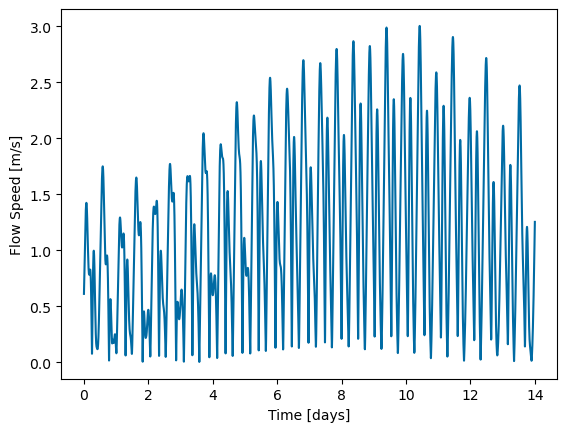

In [4]:
station = "COI0303"         # must be string; Harmonic stations only; https://tidesandcurrents.noaa.gov/noaacurrents/Stations?g=693
startdate = 20210901        # yyyyMMdd
rangeHr = 2*7*24            # two weeks
timestep = 0.25              # one second

Uinf, t ,dMoor ,buoyLatitude ,buoyLongitude = funcTidal.loadTidal(station,startdate,rangeHr,timestep)

print('Mooring depth is ' + str(dMoor) +  ' [m].')

AlaskaCityLocationData = "/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/AlaskaCityLatLong.txt"

dCable, CityName = funcTidal.calCableLen(buoyLatitude ,buoyLongitude,AlaskaCityLocationData)

print('Cable lengh is ' + str(round(dCable*CONVERT.m2mile,2)) + ' miles and the closest city is ' + CityName + '.')

plt.plot(t*CONVERT.sec2days,Uinf)
plt.xlabel('Time [days]')
plt.ylabel('Flow Speed [m/s]')

Then, we load the rotor data

In [5]:
AeroDynFolderPath = "/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/Original_MHKF1_ARLScaled_20Sections_5ms_VariedPitch_Cp/"

myTSRmax = 10.0
myTSRmin = 0.0
CpFunc,CtFunc,CpminFunc,spanRatio,CpOpt,TSROpt = funcRotor.loadRotorSurfaces(AeroDynFolderPath,myTSRmax,myTSRmin)

bladeVolume,baseMass,baseRadius,bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath) 


The information below must be specified for rotor simulation
- rotor radius, generator power rating, hub depth, minimum cut-in speed, and if we are using brakes
- Uinf, t and dMoor given by `funcTidal.loadTidal()` output
- CpFunc, CtFunc, CpOpt, TSROpt given by `funcRotor.loadRotorSurfaces()` output
- baseRadius, baseMass given by ` funcRotor.estimateRotorMass()` output

In [6]:
Radius = 1.0
Prated = 15.0e3
dHub = 2.0
Umin = 0.1
withBrake = True

w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th = funcSimRotor.simRotor(Radius, Prated, dHub, dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, Umin, withBrake)

Running rotor simulation for Radius = 1.0, Prated = 15000.0, dHub = 2.0.


Build in functions are available to compute the statictics of output of the  rotor simulation

In [7]:
funcSimRotor.printSimRotorStatistic(w,Tc,Pmech,Pelec,Phydro,Pfluid,Punc,TSR,Ft,Th)

Rotor Dynamics (Mean) [SI units are assumed]:
w: 5.05
Tc: 314.38
TSR: 4.19
Pmech: 2594.65
Pelec: 2335.18
Phydro: 2612.84
Pfluid: 6022.86
Punc: 2639.14
Ft: 2568.61
Th: 316.68
Rotor Dynamics (Max) [SI units are assumed]:
w: 12.95
Tc: 1599.16
TSR: 5.12
Pmech: 16666.67
Pelec: 15000.00
Phydro: 18930.38
Pfluid: 43632.41
Punc: 19119.17
Ft: 11978.42
Th: 1461.54


Build in functions are available to plot the time domain results
- `VESSEL` information is used for saving the output figure. Can use `None` is inapplicable

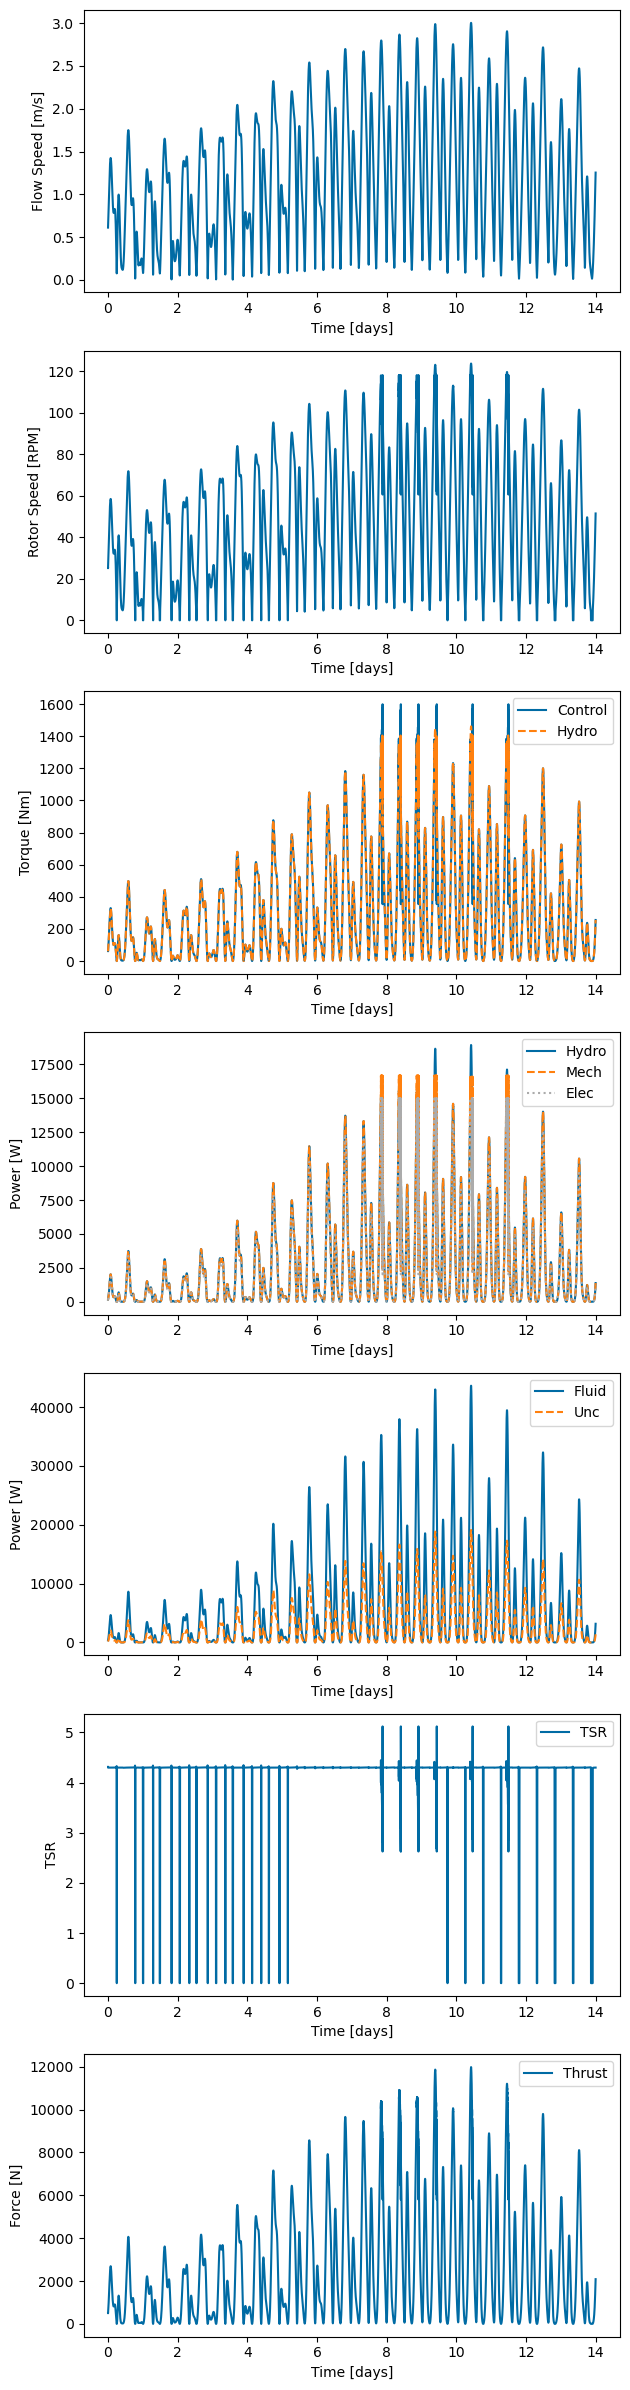

In [8]:
funcSimRotor.plotTimeDomainResult(Uinf,t, w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th, station, startdate, None, Umin, withBrake)

Using the simulation data, we can check if the vessel pitch constraint would have violate.
- We first need to load the vessel properties from `constVessel`; here we showed an example using the fishing vessel data available by default
- then we need to change the flow speed according to the hub depth and calculate the mooring thrust force and the turbine thrust force
- We have to specify the number of turbine we want to fit on our vessel

In [9]:
import constVessel
VESSEL = constVessel.FISH

import funcConstraint


NumTurbine = 3

Uinf_update = funcTidal.flowAtDepth(Uinf, Radius, dHub, dMoor)
F_vessel_thrust = funcConstraint.calForceMoorThrustFunc(Uinf_update, VESSEL)
F_turbine_thrust = funcSimRotor.calForceThrustFunc(Radius, Uinf_update, CtFunc(TSR))


Use the built in function to visualise the vessel pitch constraint

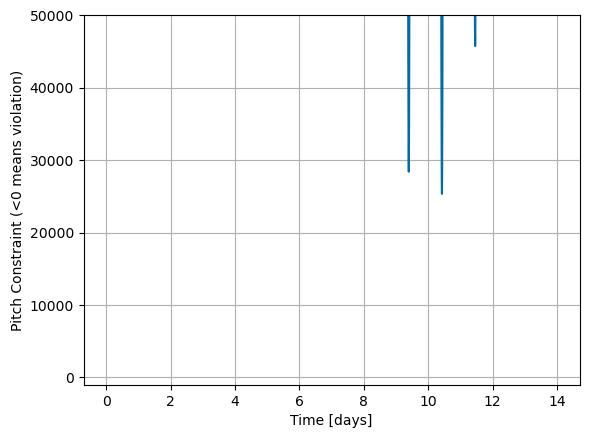

In [10]:

ylim = [-1000, 50000] # for plotting graph
funcConstraint.plotPitchCon(Radius, dHub, dMoor, Uinf, CtFunc, TSR, VESSEL, NumTurbine, t, ylim)


Use the built in function to visualise the cavitation constraint

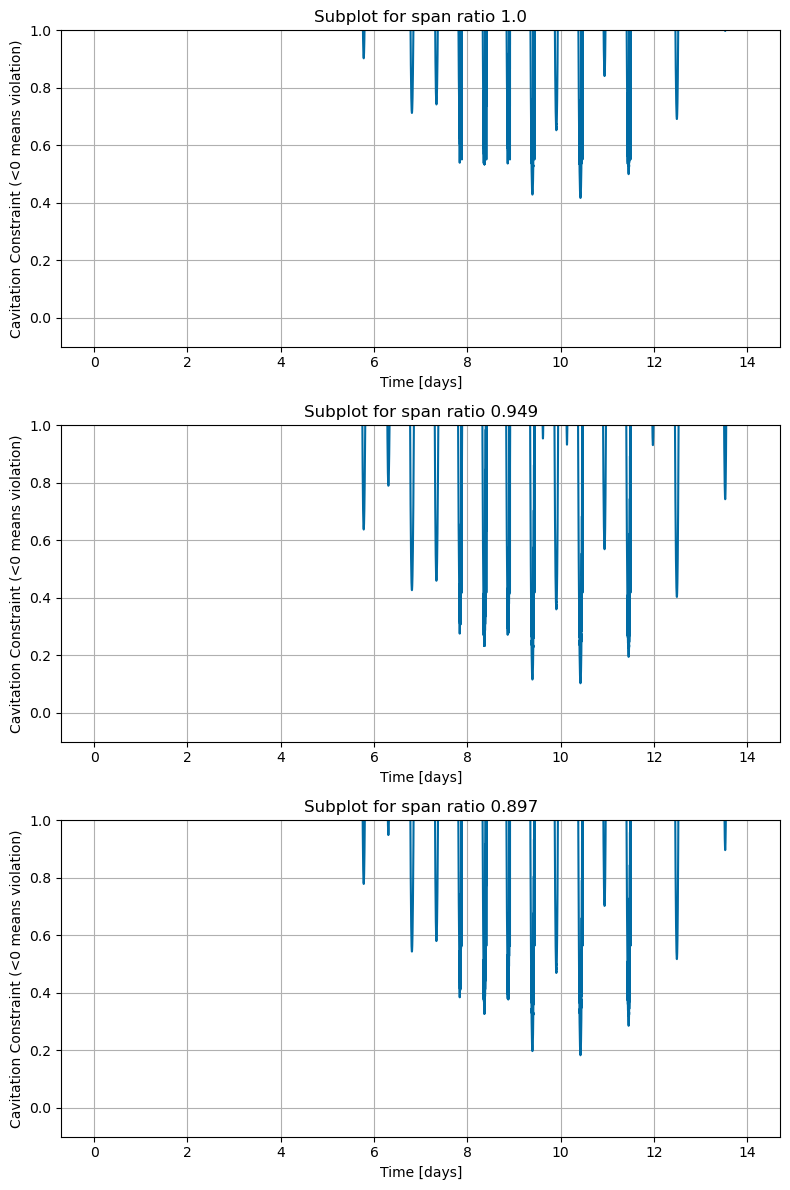

In [11]:
ylim = None
funcConstraint.plotCavitationCon(Radius, dHub, dMoor, Uinf, w, TSR, CpminFunc, spanRatio, t, ylim)

Assuming that we are happy with this design. We can calculate the LCOE using the function in `funcLCOE.py`

In [12]:
import funcLCOE

LCOE, CostBreakdown = funcLCOE.calculate_cost(Radius, Prated, NumTurbine, dCable, dMoor, F_vessel_thrust, F_turbine_thrust, Pelec, t)

In [13]:
funcLCOE.printCostBreakdown(CostBreakdown)

Cost Breakdown:
LCOE: $0.55
CAPEX: $215841.75
Et: $61412.88
cable: $59911.14
grid connect: $1281.87
moor: $5420.16
blade: $409.46
generator: $14543.25
misc: $2115.09
hub: $9485.86
cable install: $112396.73
